In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

pd.set_option('future.no_silent_downcasting', True)

df = pd.read_csv('processed_data.csv', index_col=0)
df.head()

,Age (>35),Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,Country,PrevSalary,Skills,Num_of_skills,Employed
0,0,0,Master,1,1,0,1,7,Sweden,51552,C++;Python;Git;PostgreSQL,4,0
1,0,0,Undergraduate,1,1,0,1,12,Spain,46482,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,0,0,Master,1,1,0,1,15,Germany,77290,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,0,0,Undergraduate,1,1,0,1,9,Canada,46135,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,1,0,PhD,0,1,0,0,40,Singapore,160932,C++;Python,2,0


In [2]:
# Dropping string columns
df = df.drop(columns=['EdLevel','Country','Skills'])

In [3]:
df.head()

,Age (>35),Accessibility,Employment,Gender,MentalHealth,MainBranch,YearsCode,PrevSalary,Num_of_skills,Employed
0,0,0,1,1,0,1,7,51552,4,0
1,0,0,1,1,0,1,12,46482,12,1
2,0,0,1,1,0,1,15,77290,7,0
3,0,0,1,1,0,1,9,46135,13,0
4,1,0,0,1,0,0,40,160932,2,0


In [4]:
y = df['Employed']
X = df.drop(columns=['Employed'], axis=1)

## Normalize the data

In [5]:
from sklearn.preprocessing import StandardScaler

# create a scaler object
scaler = StandardScaler()

feature_names = X.columns  # save this BEFORE scaling (when X_train is still DF)
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.7323003 , -0.17175099,  0.36376415, ..., -0.76783797,
        -0.32762037, -1.33902569],
       [-0.7323003 , -0.17175099,  0.36376415, ..., -0.23614549,
        -0.43006142, -0.20425357],
       [-0.7323003 , -0.17175099,  0.36376415, ...,  0.08286999,
         0.19242452, -0.91348614],
       ...,
       [-0.7323003 , -0.17175099,  0.36376415, ..., -1.08685345,
        -0.20299387, -0.20425357],
       [-0.7323003 ,  5.8223829 ,  0.36376415, ..., -0.98051496,
         0.04512763,  0.22128597],
       [-0.7323003 , -0.17175099,  0.36376415, ..., -0.44882248,
         0.15391315, -1.62271872]])

## Splitting the Data

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Evaluate Fairness for original data

Accuracy for female: 0.7994

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,360,112
Actual Not Employed,87,433


Accuracy for male: 0.783

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5953,1484
Actual Not Employed,1486,4764



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.76,0.17,0.83,0.24
Male,0.80,0.24,0.76,0.20


Model Accuracy (Logistic Regression): 0.784


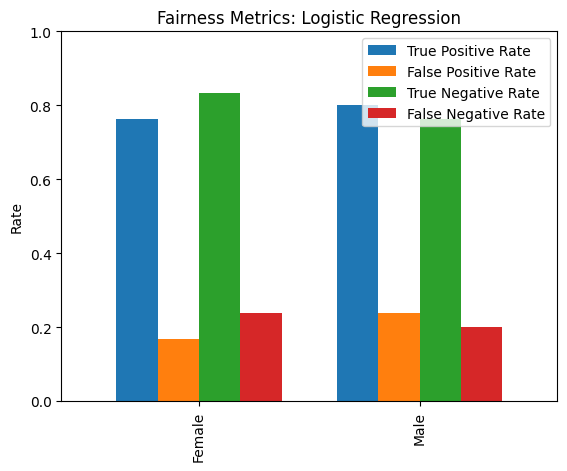

Accuracy for female: 0.756

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,357,115
Actual Not Employed,127,393


Accuracy for male: 0.7427

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5715,1722
Actual Not Employed,1799,4451



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.76,0.24,0.76,0.24
Male,0.77,0.29,0.71,0.23


Model Accuracy (Random Forest): 0.744


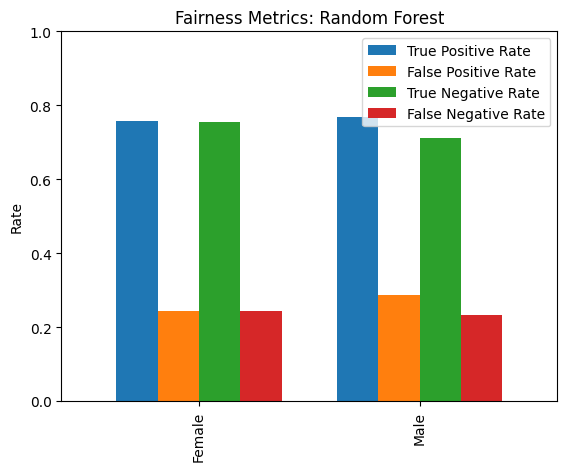

Accuracy for female: 0.8014

Confusion Matrix for Gradient Boosting (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,379,93
Actual Not Employed,104,416


Accuracy for male: 0.7851

Confusion Matrix for Gradient Boosting (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6176,1261
Actual Not Employed,1681,4569



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.80,0.20,0.80,0.20
Male,0.83,0.27,0.73,0.17


Model Accuracy (Gradient Boosting): 0.786


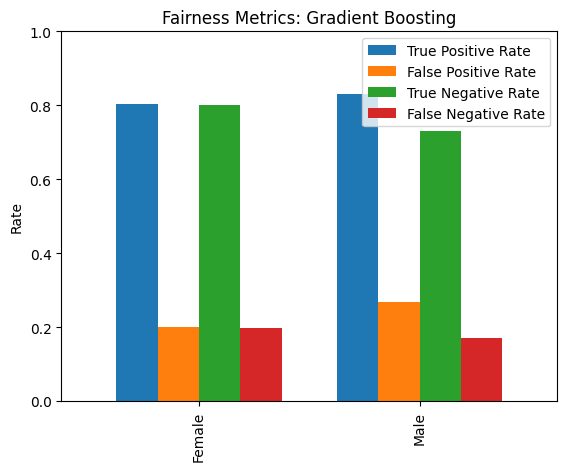

In [7]:
def evaluate_fairness(y_true, y_pred, model_name):
    # Build results dataframe
    # We are using y_test.index to ensure that we pull the correct Gender from the original dataset
    results = pd.DataFrame({
        "y_true": y_true.values, 
        "y_pred": y_pred,
        "Gender": df.loc[y_test.index, "Gender"].values
    })

    # 2) Initialize storage for this specific model
    gender_groups = [0, 1] # 0: Female, 1: Male
    genders_order = ["Female", "Male"]
    confusion_tables = {}
    current_sp = []
    current_tpr = []
    current_fpr = []
    rates = {}

    # 3) Process each gender
    for g in gender_groups:
        subset = results[results["Gender"] == g]
        gender_label = "Female" if g == 0 else "Male"
        
        # Calculate Confusion Matrix
        cm = confusion_matrix(subset["y_true"], subset["y_pred"], labels=[1, 0])
        confusion_tables[gender_label] = pd.DataFrame(
            cm, 
            index=["Actual Employed", "Actual Not Employed"],
            columns=["Predicted Employed", "Predicted Not Employed"]
        )
        
        # Extract values
        tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        
        # Calculate Metrics
        total = tp + tn + fp + fn
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan

        gender_acc = (tp + tn) / total if total > 0 else 0
        print(f"Accuracy for {gender_label.lower()}: {round(gender_acc, 4)}")
        
        # Store for the global lists (sp_lg, etc.)
        current_sp.append((tp + fp) / total)
        current_tpr.append(tpr)
        current_fpr.append(fpr)

        rates[gender_label] = {
            "True Positive Rate": tpr,
            "False Positive Rate": fpr,
            "True Negative Rate": tn / (tn + fp) if (tn + fp) else np.nan,
            "False Negative Rate": fn / (fn + tp) if (fn + tp) else np.nan
        }
        
        print(f"\nConfusion Matrix for {model_name} (Gender = {gender_label})")
        display(confusion_tables[gender_label])

    # Display Rates Table
    df_rates = pd.DataFrame(rates).T
    print("\nRates:")
    display(df_rates.round(2))

    # Show model accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Model Accuracy ({model_name}): {round(accuracy, 3)}')
    
    #  Visualization
    df_rates = pd.DataFrame(rates).T
    ax = df_rates.plot(kind="bar", width=0.75)
    plt.title(f"Fairness Metrics: {model_name}")
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.show()

    # Return the metrics so you can use them in your fairness measurements
    return current_sp, current_tpr, current_fpr

# Logistic Regression
lr_model = LogisticRegression().fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest")

# Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=100).fit(X_train, y_train)
y_pred_gbc = gbc.predict(X_test)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")

# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [8]:
# SP for Logistic Regression
print(f'Logistic Regression -> {round(sp_lg[0] / sp_lg[1], 4)} \n Random Forest -> {round(sp_rf[0] / sp_rf[1], 4)} \n Gradient Boosting -> {round(sp_gbc[0] / sp_gbc[1], 4)}')

Logistic Regression -> 0.8291 
 Random Forest -> 0.8887 
 Gradient Boosting -> 0.8482


# Equal Opportunity
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [9]:
print(f'Logistic Regression -> {round(TPR_lr[0] - TPR_lr[1], 4)} \nRandom Forest -> {round(TPR_rf[0] - TPR_rf[1], 4)} \nGradient Boosting -> {round(TPR_gbc[0] - TPR_gbc[1], 4)}')

Logistic Regression -> -0.0377 
Random Forest -> -0.0121 
Gradient Boosting -> -0.0275


# Equalized Odds

### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [10]:
print(f'Logistic Regression -> {round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)} \nRandom Forest -> {round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)} \nGradient Boosting -> {round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)}')

Logistic Regression -> -0.0541 
Random Forest -> -0.0279 
Gradient Boosting -> -0.0482


# Bias Mitigation

## Pre-Processing (Reweighting)

In [11]:
from sklearn.utils.class_weight import compute_sample_weight

# X.iloc[0:20, 3]
gender_train = X_train[:, 3]
groups = [f"{g}_{y}" for g, y in zip(gender_train, y_train)]

fairness_weights = compute_sample_weight('balanced', groups)
fairness_weights[:10]

array([0.49519279, 0.58280065, 0.58280065, 0.58280065, 7.16748047,
       0.49519279, 0.58280065, 0.49519279, 0.49519279, 0.58280065])

Accuracy for female: 0.8004

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,369,103
Actual Not Employed,95,425


Accuracy for male: 0.7758

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5636,1801
Actual Not Employed,1267,4983



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.78,0.18,0.82,0.22
Male,0.76,0.20,0.80,0.24


Model Accuracy (Logistic Regression): 0.778


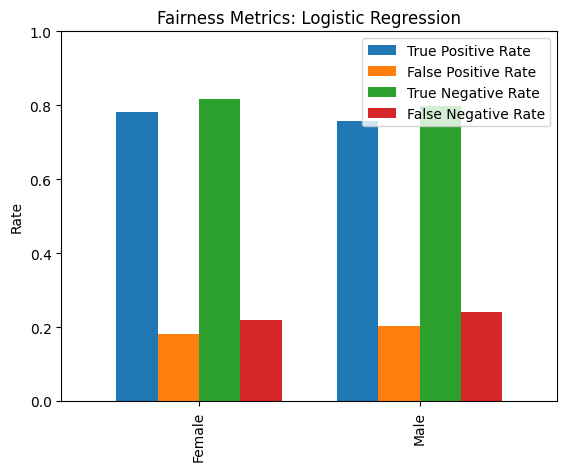

Accuracy for female: 0.7742

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,363,109
Actual Not Employed,115,405


Accuracy for male: 0.743

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5735,1702
Actual Not Employed,1815,4435



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.77,0.22,0.78,0.23
Male,0.77,0.29,0.71,0.23


Model Accuracy (Random Forest): 0.745


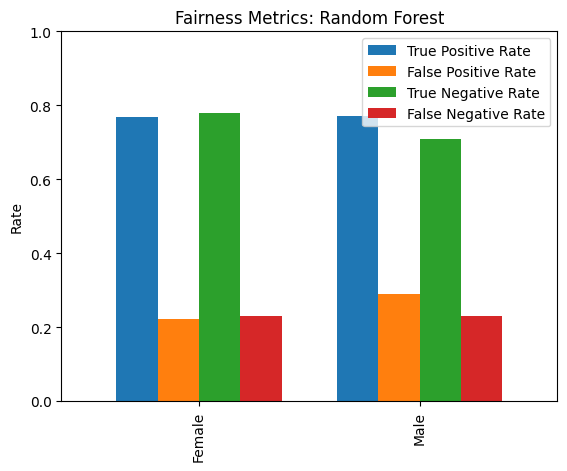

Accuracy for female: 0.7933

Confusion Matrix for Gradient Boosting (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,384,88
Actual Not Employed,117,403


Accuracy for male: 0.7826

Confusion Matrix for Gradient Boosting (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5987,1450
Actual Not Employed,1526,4724



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.81,0.22,0.78,0.19
Male,0.81,0.24,0.76,0.19


Model Accuracy (Gradient Boosting): 0.783


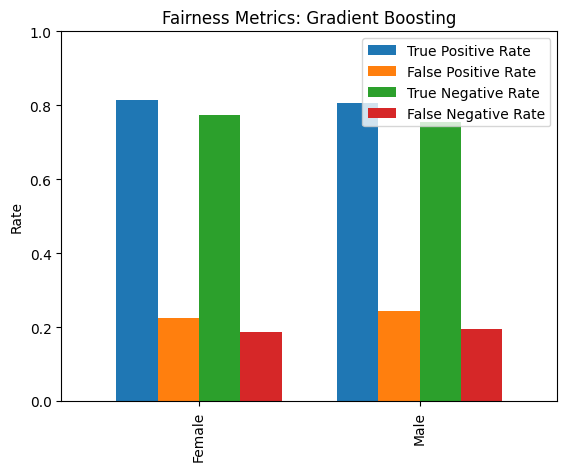

In [12]:
def evaluate_fairness(y_true, y_pred, model_name):
    # Build results dataframe
    # We are using y_test.index to ensure that we pull the correct Gender from the original dataset
    results = pd.DataFrame({
        "y_true": y_true.values, 
        "y_pred": y_pred,
        "Gender": df.loc[y_test.index, "Gender"].values
    })

    # 2) Initialize storage for this specific model
    gender_groups = [0, 1] # 0: Female, 1: Male
    genders_order = ["Female", "Male"]
    confusion_tables = {}
    current_sp = []
    current_tpr = []
    current_fpr = []
    rates = {}

    # 3) Process each gender
    for g in gender_groups:
        subset = results[results["Gender"] == g]
        gender_label = "Female" if g == 0 else "Male"
        
        # Calculate Confusion Matrix
        cm = confusion_matrix(subset["y_true"], subset["y_pred"], labels=[1, 0])
        confusion_tables[gender_label] = pd.DataFrame(
            cm, 
            index=["Actual Employed", "Actual Not Employed"],
            columns=["Predicted Employed", "Predicted Not Employed"]
        )
        
        # Extract values
        tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        
        # Calculate Metrics
        total = tp + tn + fp + fn
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan

        gender_acc = (tp + tn) / total if total > 0 else 0
        print(f"Accuracy for {gender_label.lower()}: {round(gender_acc, 4)}")
        
        # Store for the global lists (sp_lg, etc.)
        current_sp.append((tp + fp) / total)
        current_tpr.append(tpr)
        current_fpr.append(fpr)

        rates[gender_label] = {
            "True Positive Rate": tpr,
            "False Positive Rate": fpr,
            "True Negative Rate": tn / (tn + fp) if (tn + fp) else np.nan,
            "False Negative Rate": fn / (fn + tp) if (fn + tp) else np.nan
        }
        
        print(f"\nConfusion Matrix for {model_name} (Gender = {gender_label})")
        display(confusion_tables[gender_label])

    # Display Rates Table
    df_rates = pd.DataFrame(rates).T
    print("\nRates:")
    display(df_rates.round(2))

    # Show model accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Model Accuracy ({model_name}): {round(accuracy, 3)}')
    
    #  Visualization
    df_rates = pd.DataFrame(rates).T
    ax = df_rates.plot(kind="bar", width=0.75)
    plt.title(f"Fairness Metrics: {model_name}")
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.show()

    # Return the metrics so you can use them in your fairness measurements
    return current_sp, current_tpr, current_fpr

# Logistic Regression
lr_model = LogisticRegression().fit(X_train, y_train, sample_weight=fairness_weights)
y_pred_lr = lr_model.predict(X_test)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train, sample_weight=fairness_weights)
y_pred_rf = rf_model.predict(X_test)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest")

# Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=100).fit(X_train, y_train, sample_weight=fairness_weights)
y_pred_gbc = gbc.predict(X_test)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")

# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [13]:
# SP for Logistic Regression
print(f'Logistic Regression -> {round(sp_lg[0] / sp_lg[1], 4)} \n Random Forest -> {round(sp_rf[0] / sp_rf[1], 4)} \n Gradient Boosting -> {round(sp_gbc[0] / sp_gbc[1], 4)}')

Logistic Regression -> 0.9274 
 Random Forest -> 0.8735 
 Gradient Boosting -> 0.9201


# Equal Opportunity

### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [14]:
print(f'Logistic Regression -> {round(TPR_lr[0] - TPR_lr[1], 4)} \nRandom Forest -> {round(TPR_rf[0] - TPR_rf[1], 4)} \nGradient Boosting -> {round(TPR_gbc[0] - TPR_gbc[1], 4)}')

Logistic Regression -> 0.0239 
Random Forest -> -0.0021 
Gradient Boosting -> 0.0085


# Equalized Odds

### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [15]:
print(f'Logistic Regression -> {round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)} \nRandom Forest -> {round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)} \nGradient Boosting -> {round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)}')

Logistic Regression -> 0.002 
Random Forest -> -0.0357 
Gradient Boosting -> -0.0053


# In Processing (ExponentiatedGradient)

In [16]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.linear_model import LogisticRegression

gender = X['Gender']
X_train_egr, X_test_egr, y_train_egr, y_test_egr, gender_train, gender_test = train_test_split(
    X, y, gender, test_size=0.2, random_state=42
)

Accuracy for female: 0.7611

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,396,76
Actual Not Employed,161,359


Accuracy for male: 0.7654

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5947,1490
Actual Not Employed,1721,4529



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.84,0.31,0.69,0.16
Male,0.80,0.28,0.72,0.20


Model Accuracy (Logistic Regression): 0.765


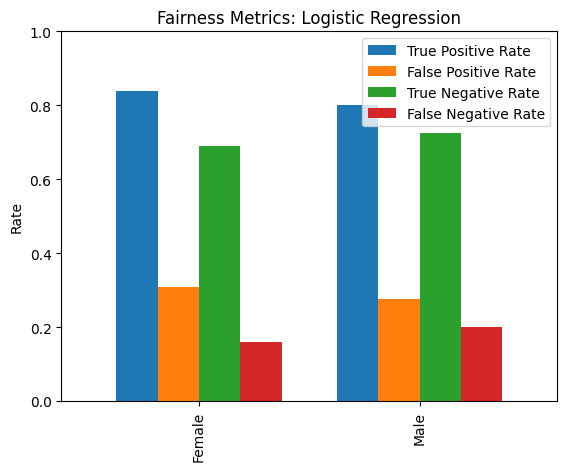

Accuracy for female: 0.7288

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,363,109
Actual Not Employed,160,360


Accuracy for male: 0.7421

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5726,1711
Actual Not Employed,1819,4431



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.77,0.31,0.69,0.23
Male,0.77,0.29,0.71,0.23


Model Accuracy (Random Forest): 0.741


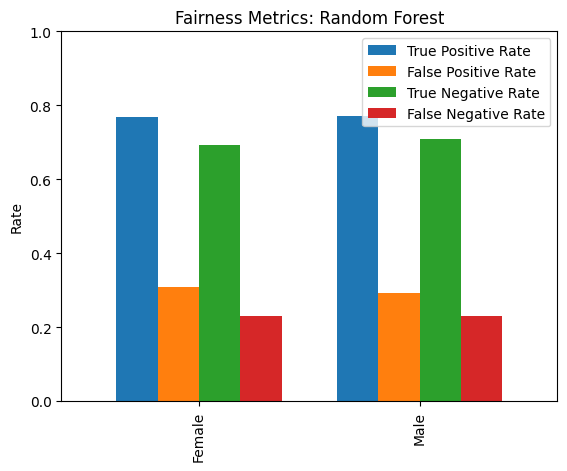

Accuracy for female: 0.7913

Confusion Matrix for Gradient Boosting (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,407,65
Actual Not Employed,142,378


Accuracy for male: 0.785

Confusion Matrix for Gradient Boosting (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6151,1286
Actual Not Employed,1657,4593



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.86,0.27,0.73,0.14
Male,0.83,0.27,0.73,0.17


Model Accuracy (Gradient Boosting): 0.785


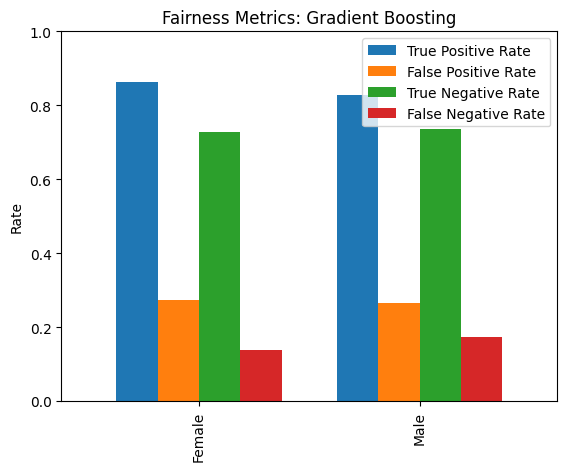

In [ ]:
def evaluate_fairness(y_true, y_pred, model_name):
    # Build results dataframe
    # We are using y_test.index to ensure that we pull the correct Gender from the original dataset
    results = pd.DataFrame({
        "y_true": y_true.values, 
        "y_pred": y_pred,
        "Gender": df.loc[y_test.index, "Gender"].values
    })

    # 2) Initialize storage for this specific model
    gender_groups = [0, 1] # 0: Female, 1: Male
    genders_order = ["Female", "Male"]
    confusion_tables = {}
    current_sp = []
    current_tpr = []
    current_fpr = []
    rates = {}

    # 3) Process each gender
    for g in gender_groups:
        subset = results[results["Gender"] == g]
        gender_label = "Female" if g == 0 else "Male"
        
        # Calculate Confusion Matrix
        cm = confusion_matrix(subset["y_true"], subset["y_pred"], labels=[1, 0])
        confusion_tables[gender_label] = pd.DataFrame(
            cm, 
            index=["Actual Employed", "Actual Not Employed"],
            columns=["Predicted Employed", "Predicted Not Employed"]
        )
        
        # Extract values
        tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        
        # Calculate Metrics
        total = tp + tn + fp + fn
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan

        gender_acc = (tp + tn) / total if total > 0 else 0
        print(f"Accuracy for {gender_label.lower()}: {round(gender_acc, 4)}")
        
        # Store for the global lists (sp_lg, etc.)
        current_sp.append((tp + fp) / total)
        current_tpr.append(tpr)
        current_fpr.append(fpr)

        rates[gender_label] = {
            "True Positive Rate": tpr,
            "False Positive Rate": fpr,
            "True Negative Rate": tn / (tn + fp) if (tn + fp) else np.nan,
            "False Negative Rate": fn / (fn + tp) if (fn + tp) else np.nan
        }
        
        print(f"\nConfusion Matrix for {model_name} (Gender = {gender_label})")
        display(confusion_tables[gender_label])

    # Display Rates Table
    df_rates = pd.DataFrame(rates).T
    print("\nRates:")
    display(df_rates.round(2))

    # Show model accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Model Accuracy ({model_name}): {round(accuracy, 3)}')
    
    #  Visualization
    df_rates = pd.DataFrame(rates).T
    ax = df_rates.plot(kind="bar", width=0.75)
    plt.title(f"Fairness Metrics: {model_name}")
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.show()

    # Return the metrics so we can use them in fairness measurements
    return current_sp, current_tpr, current_fpr

# Logistic Regression
lr_model_egr = ExponentiatedGradient(
    estimator=LogisticRegression(solver='liblinear'),
    constraints=DemographicParity()
).fit(X_train_egr, y_train_egr, sensitive_features=gender_train)
y_pred_lr = lr_model_egr.predict(X_test_egr)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test_egr, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model_egr = ExponentiatedGradient(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    constraints=DemographicParity()
).fit(X_train_egr, y_train_egr, sensitive_features=gender_train)
y_pred_rf = rf_model_egr.predict(X_test_egr)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test_egr, y_pred_rf, "Random Forest")

# Gradient Boosting
gbc_model_egr = ExponentiatedGradient(
    estimator=GradientBoostingClassifier(n_estimators=100, random_state=42),
    constraints=DemographicParity()
).fit(X_train_egr, y_train_egr, sensitive_features=gender_train)
y_pred_gbc = gbc_model_egr.predict(X_test_egr)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test_egr, y_pred_gbc, "Gradient Boosting")

# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [18]:
print(f'Logistic Regression -> {round(sp_lg[0] / sp_lg[1], 4)} \n Random Forest -> {round(sp_rf[0] / sp_rf[1], 4)} \n Gradient Boosting -> {round(sp_gbc[0] / sp_gbc[1], 4)}')

Logistic Regression -> 1.0022 
 Random Forest -> 0.9564 
 Gradient Boosting -> 0.9701


# Equal Opportunity
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [19]:
print(f'Logistic Regression -> {round(TPR_lr[0] - TPR_lr[1], 4)} \nRandom Forest -> {round(TPR_rf[0] - TPR_rf[1], 4)} \nGradient Boosting -> {round(TPR_gbc[0] - TPR_gbc[1], 4)}')

Logistic Regression -> 0.0393 
Random Forest -> -0.0009 
Gradient Boosting -> 0.0352


# Equalized Odds
### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [20]:
print(f'Logistic Regression -> {round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)} \nRandom Forest -> {round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)} \nGradient Boosting -> {round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)}')

Logistic Regression -> 0.0368 
Random Forest -> 0.0079 
Gradient Boosting -> 0.0216


# Post Processing (ThresholdOptimizer)

In [21]:
from fairlearn.postprocessing import ThresholdOptimizer

gender = X['Gender']
X_train_to, X_test_to, y_train_to, y_test_to, gender_train, gender_test = train_test_split(
    X, y, gender, test_size=0.2, random_state=42
)

Accuracy for female: 0.7964

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,397,75
Actual Not Employed,127,393


Accuracy for male: 0.7658

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5846,1591
Actual Not Employed,1614,4636



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.84,0.24,0.76,0.16
Male,0.79,0.26,0.74,0.21


Model Accuracy (Logistic Regression): 0.768


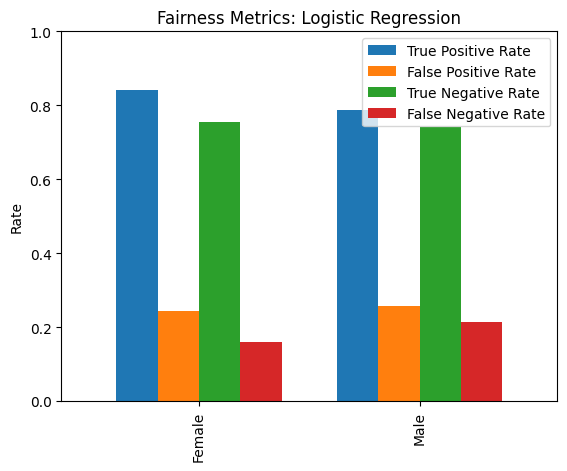

Accuracy for female: 0.7379

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,421,51
Actual Not Employed,209,311


Accuracy for male: 0.7405

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5611,1826
Actual Not Employed,1726,4524



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.89,0.40,0.60,0.11
Male,0.75,0.28,0.72,0.25


Model Accuracy (Random Forest): 0.74


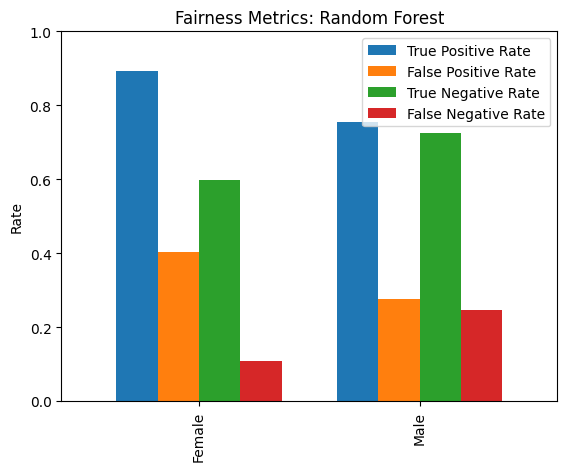

Accuracy for female: 0.7913

Confusion Matrix for Gradient Boosting (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,418,54
Actual Not Employed,153,367


Accuracy for male: 0.7846

Confusion Matrix for Gradient Boosting (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6159,1278
Actual Not Employed,1670,4580



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.89,0.29,0.71,0.11
Male,0.83,0.27,0.73,0.17


Model Accuracy (Gradient Boosting): 0.785


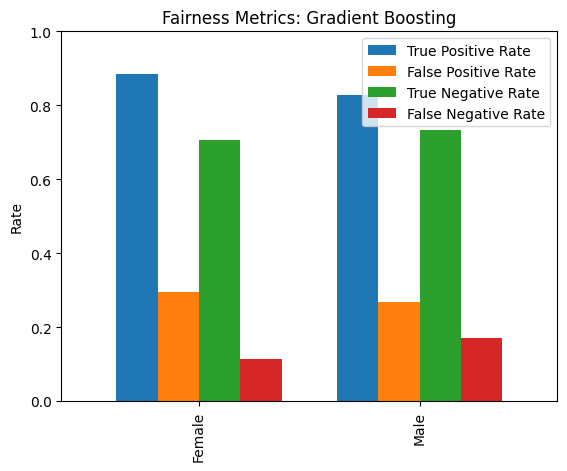

In [ ]:
def evaluate_fairness(y_true, y_pred, model_name):
    # Build results dataframe
    # We are using y_test.index to ensure that we pull the correct Gender from the original dataset
    results = pd.DataFrame({
        "y_true": y_true.values, 
        "y_pred": y_pred,
        "Gender": df.loc[y_test.index, "Gender"].values
    })

    # 2) Initialize storage for this specific model
    gender_groups = [0, 1] # 0: Female, 1: Male
    genders_order = ["Female", "Male"]
    confusion_tables = {}
    current_sp = []
    current_tpr = []
    current_fpr = []
    rates = {}

    # 3) Process each gender
    for g in gender_groups:
        subset = results[results["Gender"] == g]
        gender_label = "Female" if g == 0 else "Male"
        
        # Calculate Confusion Matrix
        cm = confusion_matrix(subset["y_true"], subset["y_pred"], labels=[1, 0])
        confusion_tables[gender_label] = pd.DataFrame(
            cm, 
            index=["Actual Employed", "Actual Not Employed"],
            columns=["Predicted Employed", "Predicted Not Employed"]
        )
        
        # Extract values
        tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        
        # Calculate Metrics
        total = tp + tn + fp + fn
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan

        gender_acc = (tp + tn) / total if total > 0 else 0
        print(f"Accuracy for {gender_label.lower()}: {round(gender_acc, 4)}")
        
        # Store for the global lists (sp_lg, etc.)
        current_sp.append((tp + fp) / total)
        current_tpr.append(tpr)
        current_fpr.append(fpr)

        rates[gender_label] = {
            "True Positive Rate": tpr,
            "False Positive Rate": fpr,
            "True Negative Rate": tn / (tn + fp) if (tn + fp) else np.nan,
            "False Negative Rate": fn / (fn + tp) if (fn + tp) else np.nan
        }
        
        print(f"\nConfusion Matrix for {model_name} (Gender = {gender_label})")
        display(confusion_tables[gender_label])

    # Display Rates Table
    df_rates = pd.DataFrame(rates).T
    print("\nRates:")
    display(df_rates.round(2))

    # Show model accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Model Accuracy ({model_name}): {round(accuracy, 3)}')
    
    #  Visualization
    df_rates = pd.DataFrame(rates).T
    ax = df_rates.plot(kind="bar", width=0.75)
    plt.title(f"Fairness Metrics: {model_name}")
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.show()

    # Return the metrics so we can use them in fairness measurements
    return current_sp, current_tpr, current_fpr

# Logistic Regression
lr_model_to = ThresholdOptimizer(
    estimator=LogisticRegression(solver='liblinear'),
    constraints="demographic_parity"
).fit(X_train_to, y_train_to, sensitive_features=gender_train)
y_pred_lr = lr_model_to.predict(X_test_to, sensitive_features=gender_test)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test_to, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model_to = ThresholdOptimizer(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    constraints="demographic_parity"
).fit(X_train_to, y_train_to, sensitive_features=gender_train)
y_pred_rf = rf_model_to.predict(X_test_to, sensitive_features=gender_test)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test_to, y_pred_rf, "Random Forest")

# Gradient Boosting
gbc_model_to = ThresholdOptimizer(
    estimator=GradientBoostingClassifier(n_estimators=100, random_state=42),
    constraints="demographic_parity"
).fit(X_train_to, y_train_to, sensitive_features=gender_train)
y_pred_gbc = gbc_model_to.predict(X_test_to, sensitive_features=gender_test)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test_to, y_pred_gbc, "Gradient Boosting")

# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [23]:
print(f'Logistic Regression -> {round(sp_lg[0] / sp_lg[1], 4)} \n Random Forest -> {round(sp_rf[0] / sp_rf[1], 4)} \n Gradient Boosting -> {round(sp_gbc[0] / sp_gbc[1], 4)}')

Logistic Regression -> 0.9691 
 Random Forest -> 1.1847 
 Gradient Boosting -> 1.0063


# Equal Opportunity
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [24]:
print(f'Logistic Regression -> {round(TPR_lr[0] - TPR_lr[1], 4)} \nRandom Forest -> {round(TPR_rf[0] - TPR_rf[1], 4)} \nGradient Boosting -> {round(TPR_gbc[0] - TPR_gbc[1], 4)}')

Logistic Regression -> 0.055 
Random Forest -> 0.1375 
Gradient Boosting -> 0.0574


# Equalized Odds
### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [25]:
print(f'Logistic Regression -> {round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)} \nRandom Forest -> {round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)} \nGradient Boosting -> {round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)}')

Logistic Regression -> 0.0205 
Random Forest -> 0.1316 
Gradient Boosting -> 0.0422
